In [10]:
import pandas as pd

income_df = pd.read_csv("Household Income.csv")
income_df['County'] = income_df['Electoral Division'].str.split(',').str[-1].str.strip()
income_2022 = income_df[income_df['Year'] == 2022]

# Keep only real county names (drop numeric codes)
real_counties = [
    'Carlow', 'Cavan', 'Clare', 'Cork City', 'Cork County', 'Donegal',
    'Dublin City', 'Dún Laoghaire-Rathdown', 'Fingal', 'South Dublin',
    'Galway City', 'Galway County', 'Kerry', 'Kildare', 'Kilkenny',
    'Laois', 'Leitrim', 'Limerick', 'Longford', 'Louth', 'Mayo', 'Meath',
    'Monaghan', 'Offaly', 'Roscommon', 'Sligo', 'Tipperary', 'Waterford',
    'Westmeath', 'Wexford', 'Wicklow'
]

income_2022 = income_2022[income_2022['County'].isin(real_counties)]

# Merge all Dublin parts into one
income_2022 = income_2022.copy()
income_2022['County'] = income_2022['County'].replace({
    'Dublin City': 'Dublin',
    'Dún Laoghaire-Rathdown': 'Dublin',
    'Fingal': 'Dublin',
    'South Dublin': 'Dublin'
})

# Merge Cork City + Cork County into Cork
income_2022['County'] = income_2022['County'].replace({
    'Cork City': 'Cork',
    'Cork County': 'Cork'
})

# Merge Galway City + Galway County into Galway
income_2022['County'] = income_2022['County'].replace({
    'Galway City': 'Galway',
    'Galway County': 'Galway'
})

income_county = income_2022.groupby('County')['VALUE'].median().reset_index()
income_county.columns = ['County', 'Median_Annual_Income']

print(income_county.shape)
print(income_county)

(26, 2)
       County  Median_Annual_Income
0      Carlow               60385.0
1       Cavan               54495.5
2       Clare               54071.0
3        Cork               60235.0
4     Donegal               44171.0
5      Dublin               68582.5
6      Galway               58695.5
7       Kerry               50584.5
8     Kildare               69678.5
9    Kilkenny               64112.0
10      Laois               64213.5
11    Leitrim               46782.5
12   Limerick               57809.5
13   Longford               53166.0
14      Louth               59408.5
15       Mayo               49928.0
16      Meath               66750.0
17   Monaghan               53955.0
18     Offaly               60837.5
19  Roscommon               53181.5
20      Sligo               52860.5
21  Tipperary               58653.0
22  Waterford               56758.0
23  Westmeath               61921.0
24    Wexford               57002.0
25    Wicklow               61662.5


In [11]:
rent_df = pd.read_csv("RTB Average Monthly Rent Report.csv")

rent_filtered = rent_df[
    (rent_df['Number of Bedrooms'] == 'All bedrooms') &
    (rent_df['Property Type'] == 'All property types') &
    (rent_df['Quarter'].str.startswith('2022'))
]

rent_filtered = rent_filtered.dropna(subset=['VALUE'])

# Keep ONLY plain county names (no towns, no commas)
# These are the 26 county-level names in the RTB data
county_only = [
    'Carlow', 'Cavan', 'Clare', 'Cork', 'Donegal', 'Dublin',
    'Galway', 'Kerry', 'Kildare', 'Kilkenny', 'Laois', 'Leitrim',
    'Limerick', 'Longford', 'Louth', 'Mayo', 'Meath', 'Monaghan',
    'Offaly', 'Roscommon', 'Sligo', 'Tipperary', 'Waterford',
    'Westmeath', 'Wexford', 'Wicklow'
]

rent_filtered = rent_filtered[rent_filtered['Location'].isin(county_only)]

rent_county = rent_filtered.groupby('Location')['VALUE'].mean().reset_index()
rent_county.columns = ['County', 'Avg_Monthly_Rent']

print(rent_county.shape)
print(rent_county)

(26, 2)
       County  Avg_Monthly_Rent
0      Carlow           1041.93
1       Cavan            817.96
2       Clare            900.32
3        Cork           1243.39
4     Donegal            714.28
5      Dublin           1874.02
6      Galway           1280.44
7       Kerry            914.59
8     Kildare           1419.30
9    Kilkenny            940.44
10      Laois            949.34
11    Leitrim            732.80
12   Limerick           1208.03
13   Longford            795.22
14      Louth           1169.87
15       Mayo            823.04
16      Meath           1286.97
17   Monaghan            763.91
18     Offaly            922.83
19  Roscommon            809.28
20      Sligo            891.98
21  Tipperary            825.53
22  Waterford           1024.07
23  Westmeath            989.69
24    Wexford            915.72
25    Wicklow           1394.80


In [12]:
rppr_df = pd.read_csv("Property Prices.csv", encoding="cp1252")

rppr_df['Price_Clean'] = rppr_df['Price (€)'].str.replace('€', '', regex=False)\
                                              .str.replace(',', '', regex=False).str.strip().astype(float)

rppr_df = rppr_df[rppr_df['Not Full Market Price'] == 'No']
rppr_df['County'] = rppr_df['County'].str.strip().str.title()

# RPPR uses "Dublin" already — but let's confirm and clean
print("Unique counties in RPPR:", sorted(rppr_df['County'].unique()))

price_county = rppr_df.groupby('County')['Price_Clean'].median().reset_index()
price_county.columns = ['County', 'Median_Sale_Price']

print(price_county)

Unique counties in RPPR: ['Carlow', 'Cavan', 'Clare', 'Cork', 'Donegal', 'Dublin', 'Galway', 'Kerry', 'Kildare', 'Kilkenny', 'Laois', 'Leitrim', 'Limerick', 'Longford', 'Louth', 'Mayo', 'Meath', 'Monaghan', 'Offaly', 'Roscommon', 'Sligo', 'Tipperary', 'Waterford', 'Westmeath', 'Wexford', 'Wicklow']
       County  Median_Sale_Price
0      Carlow          211409.69
1       Cavan          177000.00
2       Clare          225000.00
3        Cork          285000.00
4     Donegal          160000.00
5      Dublin          405000.00
6      Galway          275000.00
7       Kerry          220265.00
8     Kildare          340750.00
9    Kilkenny          239800.00
10      Laois          220000.00
11    Leitrim          155000.00
12   Limerick          230000.00
13   Longford          145000.00
14      Louth          240000.00
15       Mayo          175000.00
16      Meath          306608.00
17   Monaghan          192500.00
18     Offaly          216000.00
19  Roscommon          151500.00
20     

In [13]:
income_county['County'] = income_county['County'].str.strip().str.title()
rent_county['County'] = rent_county['County'].str.strip().str.title()
price_county['County'] = price_county['County'].str.strip().str.title()

master_df = income_county.merge(rent_county, on='County', how='inner')\
                         .merge(price_county, on='County', how='inner')

print("Final shape:", master_df.shape)
print(master_df)

Final shape: (26, 4)
       County  Median_Annual_Income  Avg_Monthly_Rent  Median_Sale_Price
0      Carlow               60385.0           1041.93          211409.69
1       Cavan               54495.5            817.96          177000.00
2       Clare               54071.0            900.32          225000.00
3        Cork               60235.0           1243.39          285000.00
4     Donegal               44171.0            714.28          160000.00
5      Dublin               68582.5           1874.02          405000.00
6      Galway               58695.5           1280.44          275000.00
7       Kerry               50584.5            914.59          220265.00
8     Kildare               69678.5           1419.30          340750.00
9    Kilkenny               64112.0            940.44          239800.00
10      Laois               64213.5            949.34          220000.00
11    Leitrim               46782.5            732.80          155000.00
12   Limerick               57

In [14]:
# Annual rent cost
master_df['Annual_Rent'] = master_df['Avg_Monthly_Rent'] * 12

# Ratio 1: Price-to-Income (how many years of income to buy a home)
master_df['Price_to_Income'] = master_df['Median_Sale_Price'] / master_df['Median_Annual_Income']

# Ratio 2: Rent-to-Income (share of annual income spent on rent)
master_df['Rent_to_Income'] = master_df['Annual_Rent'] / master_df['Median_Annual_Income']

# Normalize both to 0-1 scale (min-max)
def minmax(col):
    return (col - col.min()) / (col.max() - col.min())

master_df['PTI_norm'] = minmax(master_df['Price_to_Income'])
master_df['RTI_norm'] = minmax(master_df['Rent_to_Income'])

# Composite Index — higher score = LESS affordable
master_df['Affordability_Index'] = (master_df['PTI_norm'] + master_df['RTI_norm']) / 2

# Sort least to most affordable
master_df_sorted = master_df.sort_values('Affordability_Index', ascending=False).reset_index(drop=True)

print(master_df_sorted[['County', 'Price_to_Income', 'Rent_to_Income', 'Affordability_Index']].to_string())

       County  Price_to_Income  Rent_to_Income  Affordability_Index
0      Dublin         5.905297        0.327901             0.937609
1     Wicklow         6.358386        0.271439             0.822451
2      Galway         4.685197        0.261780             0.561678
3     Kildare         4.890318        0.244431             0.535369
4        Cork         4.731468        0.247708             0.523799
5       Meath         4.593378        0.231365             0.453394
6    Limerick         3.978585        0.250761             0.429728
7       Louth         4.039826        0.236304             0.392698
8       Kerry         4.354397        0.216965             0.375204
9   Waterford         4.140385        0.216513             0.344312
10      Clare         4.161195        0.199808             0.294648
11    Wexford         4.080541        0.192776             0.261429
12     Carlow         3.501030        0.207057             0.226538
13  Westmeath         3.714410        0.191797  

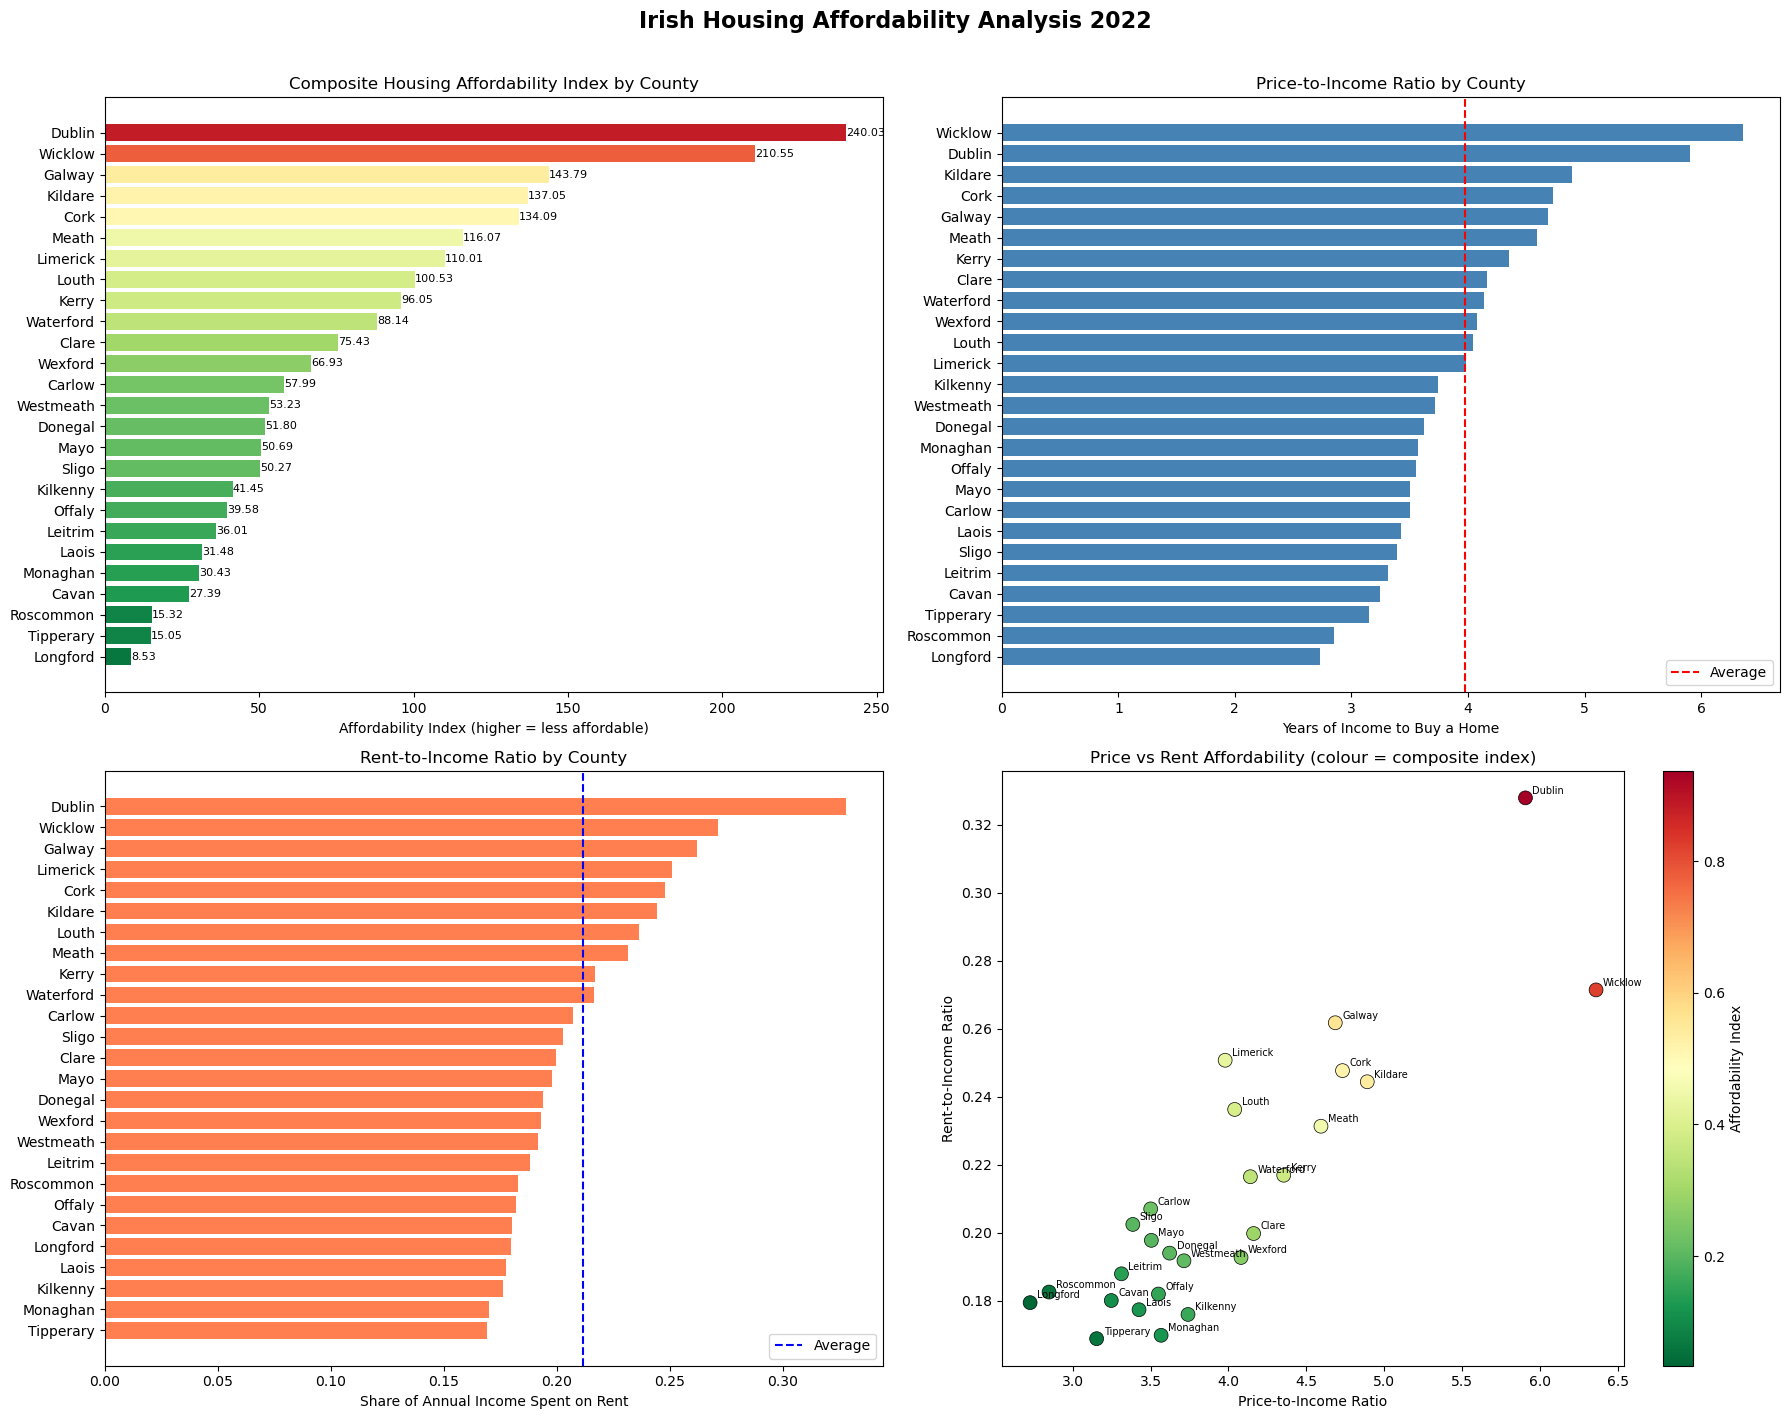

Chart saved as affordability_index.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Irish Housing Affordability Analysis 2022', fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Composite Affordability Index (bar chart) ---
colors = cm.RdYlGn_r(master_df_sorted['Affordability_Index'])
bars = axes[0, 0].barh(master_df_sorted['County'], master_df_sorted['Affordability_Index'], color=colors)
axes[0, 0].set_xlabel('Affordability Index (higher = less affordable)')
axes[0, 0].set_title('Composite Housing Affordability Index by County')
axes[0, 0].invert_yaxis()
for bar, val in zip(bars, master_df_sorted['Affordability_Index']):
    axes[0, 0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center', fontsize=8)

# --- Chart 2: Price-to-Income Ratio ---
pti_sorted = master_df.sort_values('Price_to_Income', ascending=False)
axes[0, 1].barh(pti_sorted['County'], pti_sorted['Price_to_Income'], color='steelblue')
axes[0, 1].set_xlabel('Years of Income to Buy a Home')
axes[0, 1].set_title('Price-to-Income Ratio by County')
axes[0, 1].invert_yaxis()
axes[0, 1].axvline(x=master_df['Price_to_Income'].mean(), color='red', linestyle='--', label='Average')
axes[0, 1].legend()

# --- Chart 3: Rent-to-Income Ratio ---
rti_sorted = master_df.sort_values('Rent_to_Income', ascending=False)
axes[1, 0].barh(rti_sorted['County'], rti_sorted['Rent_to_Income'], color='coral')
axes[1, 0].set_xlabel('Share of Annual Income Spent on Rent')
axes[1, 0].set_title('Rent-to-Income Ratio by County')
axes[1, 0].invert_yaxis()
axes[1, 0].axvline(x=master_df['Rent_to_Income'].mean(), color='blue', linestyle='--', label='Average')
axes[1, 0].legend()

# --- Chart 4: Scatter — PTI vs RTI with county labels ---
scatter = axes[1, 1].scatter(
    master_df['Price_to_Income'],
    master_df['Rent_to_Income'],
    c=master_df['Affordability_Index'],
    cmap='RdYlGn_r', s=100, edgecolors='black', linewidth=0.5
)
for _, row in master_df.iterrows():
    axes[1, 1].annotate(row['County'],
                        (row['Price_to_Income'], row['Rent_to_Income']),
                        textcoords="offset points", xytext=(5, 3), fontsize=7)
axes[1, 1].set_xlabel('Price-to-Income Ratio')
axes[1, 1].set_ylabel('Rent-to-Income Ratio')
axes[1, 1].set_title('Price vs Rent Affordability (colour = composite index)')
plt.colorbar(scatter, ax=axes[1, 1], label='Affordability Index')

plt.tight_layout()
plt.savefig('affordability_index.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as affordability_index.png")

In [16]:
summary = master_df_sorted[[
    'County', 'Median_Annual_Income', 'Avg_Monthly_Rent',
    'Median_Sale_Price', 'Price_to_Income', 'Rent_to_Income', 'Affordability_Index'
]].copy()

summary['Median_Annual_Income'] = summary['Median_Annual_Income'].map('€{:,.0f}'.format)
summary['Avg_Monthly_Rent']     = summary['Avg_Monthly_Rent'].map('€{:,.0f}'.format)
summary['Median_Sale_Price']    = summary['Median_Sale_Price'].map('€{:,.0f}'.format)
summary['Price_to_Income']      = summary['Price_to_Income'].map('{:.2f}x'.format)
summary['Rent_to_Income']       = summary['Rent_to_Income'].map('{:.1%}'.format)
summary['Affordability_Index']  = summary['Affordability_Index'].map('{:.2f}'.format)

print(summary.to_string(index=False))

# Save to CSV for your report
master_df_sorted.to_csv('affordability_results.csv', index=False)
print("\nSaved to affordability_results.csv")

   County Median_Annual_Income Avg_Monthly_Rent Median_Sale_Price Price_to_Income Rent_to_Income Affordability_Index
   Dublin              €68,582           €1,874          €405,000           5.91x          32.8%              240.03
  Wicklow              €61,662           €1,395          €392,074           6.36x          27.1%              210.55
   Galway              €58,696           €1,280          €275,000           4.69x          26.2%              143.79
  Kildare              €69,678           €1,419          €340,750           4.89x          24.4%              137.05
     Cork              €60,235           €1,243          €285,000           4.73x          24.8%              134.09
    Meath              €66,750           €1,287          €306,608           4.59x          23.1%              116.07
 Limerick              €57,810           €1,208          €230,000           3.98x          25.1%              110.01
    Louth              €59,408           €1,170          €240,00